In [264]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium

In [265]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from scipy.signal import find_peaks

In [266]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [267]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 5 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [268]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [269]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                return result
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [270]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [271]:
train_candles = fetch_candle_data(100)
train_df = pd.DataFrame(train_candles['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])

#train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

5112
5112


In [272]:

class DataProcessor:
    def __init__(self, train_df, peak_length=14, indicator_length=14):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param train_df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.train_df = train_df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.train_df.columns:
            self.train_df['volume'] = self.train_df['volume'].fillna(0)
            if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
                self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        # Relative Strength Index (RSI): Measures momentum and identifies overbought/oversold conditions.
        self.train_df['rsi'] = ta.rsi(self.train_df['close'], length=self.indicator_length)

        # Exponential Moving Average (EMA): Highlights price trends by smoothing data.
        self.train_df['ema'] = ta.ema(self.train_df['close'], length=self.indicator_length)

        # Average True Range (ATR): Indicates market volatility.
        self.train_df['atr'] = ta.atr(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)

        # Bollinger Bands (BB): Identify price volatility and potential breakout zones.
        bbands = ta.bbands(self.train_df['close'], length=self.indicator_length)
        self.train_df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        # Historical Volatility (HV): Measures standard deviation of returns to capture market risk.
        self.train_df['hv'] = self.train_df['close'].pct_change().rolling(self.indicator_length).std() * (252 ** 0.5)

        # Price Spread Dynamics: Represents the difference between open and close relative to range.
        self.train_df['price_spread'] = (self.train_df['close'] - self.train_df['open']) / (
                self.train_df['high'] - self.train_df['low'])

        # Candle Length-to-ATR Ratio: Normalizes candle size by ATR to detect extremes.
        self.train_df['candle_to_atr'] = (self.train_df['high'] - self.train_df['low']) / self.train_df['atr']

        # Time-of-Day and Day-of-Week Features
        self.train_df['hour'] = self.train_df.index.hour
        self.train_df['day_of_week'] = self.train_df.index.dayofweek

        # Rate of Change (ROC)
        self.train_df['roc'] = ta.roc(self.train_df['close'], length=self.indicator_length)

        # Price Change
        self.train_df['price_change'] = self.train_df['close'].diff()

        # Target and Stop Loss based on ATR
        self.train_df['Target'] = self.train_df['atr'] * 2
        self.train_df['Stop Loss'] = self.train_df['atr']

        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        # Resistance (local maxima): Identifies potential sell zones.
        resistance_peaks, _ = find_peaks(self.train_df['high'], distance=self.peak_length)
        self.train_df['resistance'] = 0.0
        self.train_df.loc[self.train_df.index[resistance_peaks], 'resistance'] = self.train_df['high'].iloc[resistance_peaks]

        # Support (local minima): Identifies potential buy zones.
        support_peaks, _ = find_peaks(-self.train_df['low'], distance=self.peak_length)
        self.train_df['support'] = 0.0
        self.train_df.loc[self.train_df.index[support_peaks], 'support'] = self.train_df['low'].iloc[support_peaks]

        return self

    def detect_market_conditions(self):
        """
        Add features to detect market conditions (trending, range-bound, or volatile).
        """
        # Average Directional Index (ADX): Measures trend strength.
        adx = ta.adx(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)
        self.train_df['adx'] = adx['ADX_' + str(self.indicator_length)]

        # RSI Oscillation Detection: Captures range-bound markets with RSI in the mid-zone.
        self.train_df['rsi_oscillation'] = ((self.train_df['rsi'] > 40) & (self.train_df['rsi'] < 60)).astype(int)

        # Price Compression Ratio: Identifies potential breakouts by comparing ATR to historical range.
        self.train_df['compression_ratio'] = self.train_df['atr'] / (
                self.train_df['high'].rolling(self.indicator_length).max()
                - self.train_df['low'].rolling(self.indicator_length).min()
        )
        return self

    def detect_market_regime(self):
        """
        Efficiently detect market regimes and assign integer labels:
        0 - Sideways, 1 - Trending, 2 - Volatile
        """
        self.train_df['market_regime'] = 0  # Default regime

        # Trending markets: Strong ADX
        trending_threshold = 25
        self.train_df.loc[self.train_df['adx'] > trending_threshold, 'market_regime'] = 1

        # Volatile markets: High Bollinger Band width
        self.train_df.loc[
            (self.train_df['bb_upper'] - self.train_df['bb_lower']) / self.train_df['bb_middle'] > 0.05,
            'market_regime'
        ] = 2

        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        return (
            self.preprocess_datetime()
            .clean_data()
            .add_indicators()
            .calculate_support_resistance()
            .detect_market_conditions()
            .detect_market_regime()
            .finalize()
        )

    def finalize(self):
        """
        Finalize the dataset by dropping rows with NaN values in any column.
        """
        self.train_df.dropna(inplace=True)
        return self



# 1. Data Preprocessing
data_processor = DataProcessor(train_df, peak_length=50, indicator_length=14)
processed_df = data_processor.process().train_df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,...,roc,price_change,Target,Stop Loss,resistance,support,adx,rsi_oscillation,compression_ratio,market_regime
datetime,,,,,,,,,,,,,,,,,,,,,
2024-09-12 11:30:00,51086.20,51155.70,51077.25,51142.60,46.940729,51154.833505,69.003240,51216.922481,51151.096429,51085.270376,...,-0.016617,62.45,138.006480,69.003240,0.0,0.0,23.090144,1,0.345968,0
2024-09-12 11:35:00,51142.10,51214.90,51130.70,51188.00,52.007349,51159.255704,70.244577,51222.429688,51153.978571,51085.527455,...,0.078889,45.40,140.489154,70.244577,0.0,0.0,22.111435,1,0.352191,0
2024-09-12 11:40:00,51191.95,51215.45,51177.10,51204.25,53.711137,51165.254944,67.665738,51230.639602,51157.435714,51084.231827,...,0.094613,16.25,135.331476,67.665738,0.0,0.0,21.247377,1,0.339262,0
2024-09-12 11:45:00,51200.50,51225.25,51152.10,51155.70,48.204925,51163.980951,68.105028,51221.386599,51153.714286,51086.041972,...,-0.101742,-48.55,136.210055,68.105028,0.0,0.0,21.132828,1,0.340100,0
2024-09-12 11:50:00,51150.35,51173.20,51128.20,51149.75,47.561414,51162.083491,66.270225,51221.704270,51154.414286,51087.124301,...,0.019163,-5.95,132.540449,66.270225,0.0,0.0,21.581293,1,0.330937,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20 15:05:00,50773.90,50773.90,50711.50,50740.30,31.098193,50843.699069,86.561542,51039.283938,50848.350000,50657.416062,...,-0.526770,-32.85,173.123084,86.561542,0.0,0.0,49.496514,0,0.215703,1
2024-12-20 15:10:00,50745.05,50770.15,50688.25,50688.35,28.420713,50822.985860,86.228575,51014.253591,50826.196429,50638.139266,...,-0.608155,-51.95,172.457149,86.228575,0.0,0.0,50.854139,0,0.214873,1
2024-12-20 15:15:00,50690.95,50770.10,50686.85,50735.95,34.025668,50811.381079,86.015819,50995.639747,50812.150000,50628.660253,...,-0.386098,47.60,172.031639,86.015819,0.0,0.0,52.121519,0,0.220243,1


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


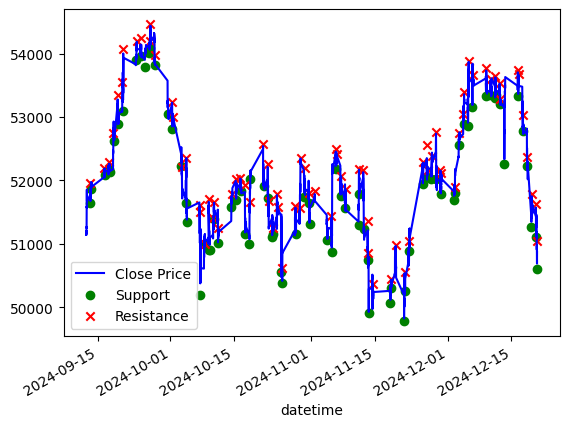

In [273]:
# Create a copy of the support and resistance columns to avoid modifying the original DataFrame
support_filtered = processed_df['support'].replace(0.0, float('nan'))
resistance_filtered = processed_df['resistance'].replace(0.0, float('nan'))

# Plot the close price
processed_df['close'].plot(label='Close Price', color='blue')

# Plot the support and resistance points, excluding 0/0.0 values
plt.scatter(processed_df.index, support_filtered, label='Support', color='green', marker='o')
plt.scatter(processed_df.index, resistance_filtered, label='Resistance', color='red', marker='x')

# Add legend and show plot
plt.legend()
plt.show()

In [297]:

class TradingEnvironment(gym.Env):
    def __init__(self, processed_df, initial_capital=100000, lot_size=15, brokerage=20):
        super(TradingEnvironment, self).__init__()

        # Store datetime index separately and reset it
        self.dates = processed_df.index
        self.data = processed_df.reset_index(drop=True)

        # Parameters
        self.initial_capital = initial_capital
        self.lot_size = lot_size  # Number of lots to trade
        self.brokerage = brokerage  # Brokerage charge per transaction (₹20)

        # Action space: 0 - Hold, 1 - Buy, 2 - Sell
        self.action_space = spaces.Discrete(3)

        # Observation space
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.data.shape[1],), dtype=np.float32
        )

        # Internal state
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.capital = self.initial_capital
        self.position = 0
        self.entry_price = 0
        self.total_trades = 0
        self.profitable_trades = 0
        return self.data.iloc[self.current_step].values, {}

    def step(self, action):
        reward = 0
        current_row = self.data.iloc[self.current_step]
        current_price = current_row["close"]
        stop_loss = current_row["Stop Loss"]
        target = current_row["Target"]

        # Check market conditions
        market_regime = current_row["market_regime"]
        rsi = current_row["rsi"]
        adx = current_row["adx"]
        compression_ratio = current_row["compression_ratio"]

        # Check if position needs to be closed
        if self.position > 0:  # Long position
            if current_price <= self.entry_price - stop_loss:  # Stop-loss hit
                reward = self._close_position(current_price, penalty=True, market_regime=market_regime, rsi=rsi, adx=adx)
            elif current_price >= self.entry_price + target:  # Target hit
                reward = self._close_position(current_price, penalty=False, market_regime=market_regime, rsi=rsi, adx=adx)

        elif self.position < 0:  # Short position
            if current_price >= self.entry_price + stop_loss:  # Stop-loss hit
                reward = self._close_position(current_price, penalty=True, market_regime=market_regime, rsi=rsi, adx=adx)
            elif current_price <= self.entry_price - target:  # Target hit
                reward = self._close_position(current_price, penalty=False, market_regime=market_regime, rsi=rsi, adx=adx)

        # Execute new action if no open position
        if action == 1 and self.position == 0:  # Buy
            self._open_position(current_price, direction=1)
        elif action == 2 and self.position == 0:  # Sell
            self._open_position(current_price, direction=-1)

        # Update environment
        self.current_step += 1
        terminated = self.current_step >= len(self.data) - 1

        # Calculate portfolio value
        portfolio_value = self.capital + self._calculate_unrealized_pnl(current_price)
        obs = self.data.iloc[self.current_step].values
        info = {
            "capital": self.capital,
            "portfolio_value": portfolio_value,
            "win_rate": (self.profitable_trades / self.total_trades * 100) if self.total_trades > 0 else 0,
            "total_trades": self.total_trades,
            "profitable_trades": self.profitable_trades,
            "datetime": self.dates[self.current_step],
        }
        return obs, reward, terminated, False, info

    def _open_position(self, price, direction):
        """Open a position with specified direction (1 for buy, -1 for sell)."""
        self.entry_price = price
        self.position = self.lot_size * direction
        self.capital -= self.brokerage  # Deduct brokerage on entry
        self.total_trades += 1

    def _close_position(self, price, penalty, market_regime, rsi, adx):
        """Close the current position and calculate reward based on realized PnL and market conditions."""
        pnl = (price - self.entry_price) * self.position if self.position > 0 else (self.entry_price - price) * abs(self.position)
        reward = (pnl / self.capital) * 100  # Percentage PnL relative to current capital
        self.capital += pnl - self.brokerage  # Deduct brokerage on exit

        # Apply penalties or rewards based on market conditions
        if pnl > 0:  # Profitable trade
            reward += self._market_condition_reward(market_regime, rsi, adx, action_type='profit')
            self.profitable_trades += 1
        elif penalty:  # Penalty for stop-loss
            reward -= 1  # Minor penalty (1%)
            reward -= self._market_condition_reward(market_regime, rsi, adx, action_type='penalty')

        self.position = 0
        self.entry_price = 0
        return reward

    def _market_condition_reward(self, market_regime, rsi, adx, action_type):
        """Reward or penalize based on market conditions like RSI, ADX, and market regime."""
        reward = 0

        # Trend-following logic
        if market_regime == 1:  # Trending market
            if action_type == 'profit':
                reward += 2  # Reward more for successful trades in trending markets
            elif action_type == 'penalty':
                reward -= 2  # Heavier penalty in trending markets for wrong trades

        elif market_regime == 0:  # Sideways market
            if action_type == 'penalty':
                reward -= 1  # Light penalty for wrong trades in sideways markets

        # RSI logic
        if rsi < 30 and action_type == 'profit':  # Oversold condition (good for buying)
            reward += 1
        elif rsi > 70 and action_type == 'profit':  # Overbought condition (good for selling)
            reward += 1
        elif (rsi < 30 and action_type == 'penalty') or (rsi > 70 and action_type == 'penalty'):
            reward -= 1  # Penalize trades against RSI signals

        # ADX logic: Strong trends (ADX > 25) should be rewarded
        if adx > 25 and action_type == 'profit':
            reward += 2  # Reward for trades in strong trends
        elif adx < 25 and action_type == 'penalty':
            reward -= 2  # Penalize if position is taken against weak trends

        return reward

    def _calculate_unrealized_pnl(self, current_price):
        """Calculate unrealized PnL for the current position."""
        if self.position > 0:
            return (current_price - self.entry_price) * self.position
        elif self.position < 0:
            return (self.entry_price - current_price) * abs(self.position)
        return 0

In [298]:
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Assuming `processed_df` is a preprocessed DataFrame with columns "close", "Stop Loss", "Target"
# Replace with your actual DataFrame
# processed_df = pd.read_csv("your_data.csv")  # Load your processed DataFrame

# Create the environment
env = TradingEnvironment(processed_df=processed_df)

# Wrap the environment to make it compatible with Stable-Baselines3
env = DummyVecEnv([lambda: env])

# Initialize the PPO model
model = PPO("MlpPolicy", env, verbose=1)

# Train the model
timesteps = 10000  # Adjust the number of timesteps
model.learn(total_timesteps=timesteps)

# Save the model
model.save("ppo_trading_model")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 667  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 566        |
|    iterations           | 2          |
|    time_elapsed         | 7          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00713984 |
|    clip_fraction        | 0.00972    |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.09      |
|    explained_variance   | -0.000344  |
|    learning_rate        | 0.0003     |
|    loss                 | 3.47       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.000986  |
|    value_loss           | 10.2       |
----------------------------------------
-----------------------------------

In [299]:
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# Load the trained model
model = PPO.load("ppo_trading_model")

# Create a fresh environment for testing
test_env = TradingEnvironment(processed_df=processed_df)
obs, _ = test_env.reset()
done = False
cumulative_reward = 0

# Lists for visualization
portfolio_values = []
capital_values = []
win_rates = []
steps = []
trade_count = 0

while not done:
    action, _states = model.predict(obs)  # Predict action
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated
    cumulative_reward += reward

    # Append values for visualization
    portfolio_values.append(info["portfolio_value"])
    capital_values.append(info["capital"])
    win_rates.append(info["win_rate"])
    steps.append(test_env.current_step)
    trade_count = info["total_trades"]

    # Print detailed information for each step
    print(
        f"Step: {test_env.current_step}, "
        f"Action: {action}, "
        f"Reward: {reward:.2f}, "
        f"Capital: {info['capital']:.2f}, "
        f"Portfolio Value: {info['portfolio_value']:.2f}, "
        f"Win Rate: {info['win_rate']:.2f}, "
        f"Total Trades: {info['total_trades']}, "
        f"Profitable Trades: {info['profitable_trades']}"
    )

# Final Statistics
print("\nFinal Analysis:")
print(f"Total Capital: {capital_values[-1]:.2f}")
print(f"Final Portfolio Value: {portfolio_values[-1]:.2f}")
print(f"Total Trades: {trade_count}")
print(f"Win Rate: {win_rates[-1]:.2f}%")

Streaming output truncated to the last 5000 lines.
Step: 91, Action: 1, Reward: 0.00, Capital: 105004.50, Portfolio Value: 106482.75, Win Rate: 44.44, Total Trades: 9, Profitable Trades: 4
Step: 92, Action: 2, Reward: 0.00, Capital: 105004.50, Portfolio Value: 106386.00, Win Rate: 44.44, Total Trades: 9, Profitable Trades: 4
Step: 93, Action: 0, Reward: 0.00, Capital: 105004.50, Portfolio Value: 106392.75, Win Rate: 44.44, Total Trades: 9, Profitable Trades: 4
Step: 94, Action: 2, Reward: 6.64, Capital: 106682.00, Portfolio Value: 106682.00, Win Rate: 50.00, Total Trades: 10, Profitable Trades: 5
Step: 95, Action: 1, Reward: 0.00, Capital: 106682.00, Portfolio Value: 106631.00, Win Rate: 50.00, Total Trades: 10, Profitable Trades: 5
Step: 96, Action: 0, Reward: 0.00, Capital: 106682.00, Portfolio Value: 106500.50, Win Rate: 50.00, Total Trades: 10, Profitable Trades: 5
Step: 97, Action: 2, Reward: 0.00, Capital: 106682.00, Portfolio Value: 108079.25, Win Rate: 50.00, Total Trades: 10, 

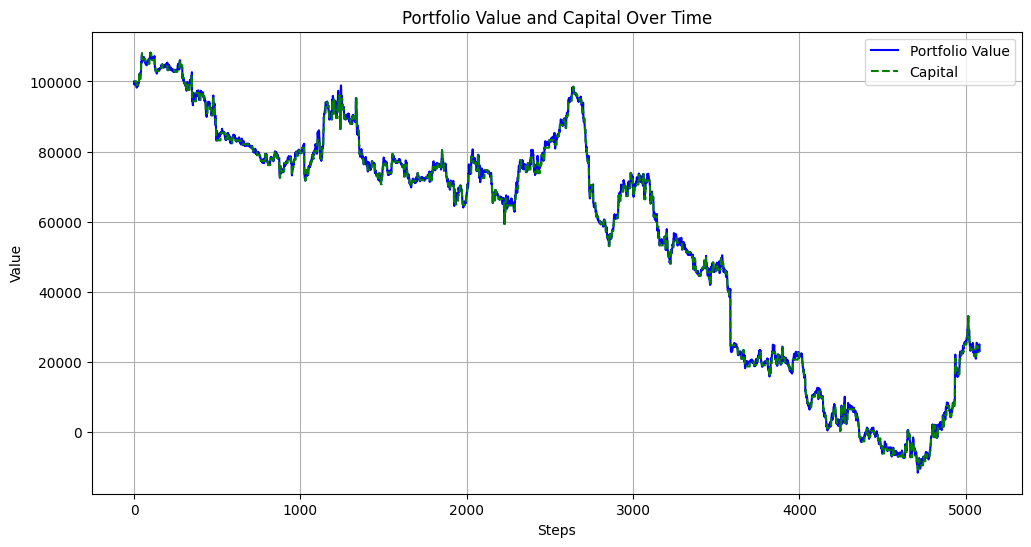

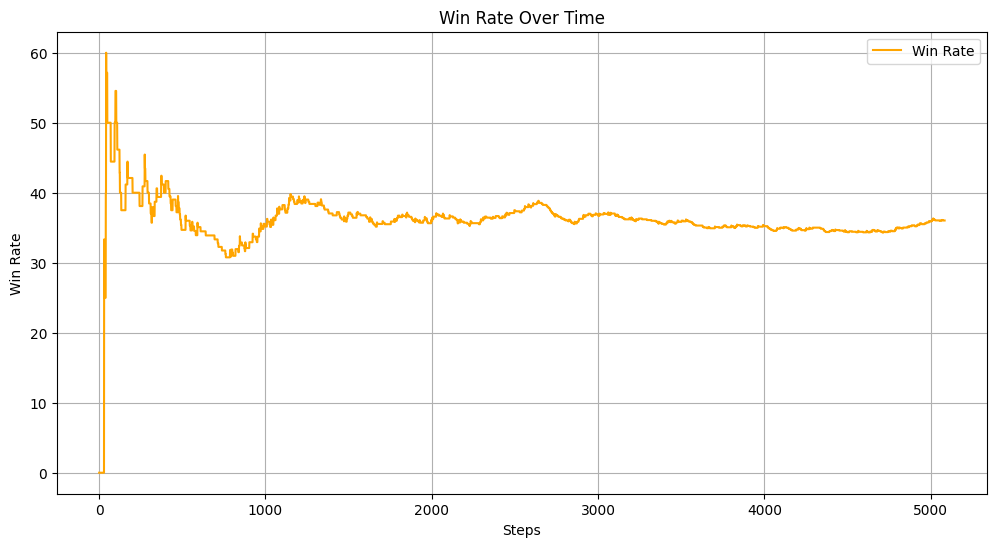

In [300]:
# Visualization
plt.figure(figsize=(12, 6))

# Portfolio Value Over Time
plt.plot(steps, portfolio_values, label="Portfolio Value", color="blue")
plt.plot(steps, capital_values, label="Capital", color="green", linestyle="--")
plt.title("Portfolio Value and Capital Over Time")
plt.xlabel("Steps")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# Win Rate Over Time
plt.figure(figsize=(12, 6))
plt.plot(steps, win_rates, label="Win Rate", color="orange")
plt.title("Win Rate Over Time")
plt.xlabel("Steps")
plt.ylabel("Win Rate")
plt.legend()
plt.grid(True)
plt.show()